# Plato light curves of exomoons

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [198]:
import os
import sys
import glob
import json

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy import constants as c

# Pandora-moon
import pandoramoon as pandora
from pandoramoon.helpers import ld_convert, ld_invert
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

# PlatoSim functions
import platosim.plot      as pt
import platosim.utilities as ut 
import platosim.starquery as sq
import platosim.smbhb     as bh
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In [276]:
def semimajor_axis(M, P):
    """Semimajor axis of system [SI units]
    """
    return (c.G.value * M * P**2 / (4 * np.pi**2))**(1/3)

## Load PlatoSim light curve

In [123]:
# Change path to where you store your downloaded catalogues
path = Path(os.getenv('PLATO_WORKDIR')) / 'cs-exomoon/simulations'
idir = path / 'mag085'
vdir = path / 'varsource'

Load and define simulated data

In [201]:
dt = pd.read_feather(idir / 'lc_000000003.tab')
df = pd.read_feather(idir / 'lc_000000003.ftr')
df.time /= 86400

In [203]:
dv = pd.read_csv(vdir / 'varsource_000000003.txt', sep=' ', names=['time', 'dmag'])
dv['flux'] = ut.fromMagToFlux(dv.dmag)
dv.time /= 86400

In [293]:
# Stellar parameters
M_star = c.M_sun.value  # [kg]
R_star = c.R_sun.value  # [m]
q1 = 0.399
q2 = 0.381
# Planet parameters
M_planet = 9.5e-4 * M_star  # [kg]
R_planet = 69_911_000       # [m]
P_planet = 365.25           # [d]
a_planet = semimajor_axis(M_sun+M_planet, P_planet*86400) # [m]
t0_bary  = 5                # [d]
t0_boff  = 0                # [d]
T_tot    = 1                # [d]
# Moon parameters
M_moon = 0.05395 * M_planet  # [kg]
R_moon = 12_742_000          # [m]
P_moon = 6.82                # [d]
a_moon = semimajor_axis(M_planet+M_moon, P_moon*86400) # [m]

In [ ]:
R_planet / R_star, R_moon / R_star, 

In [294]:
M_planet / M_star, M_moon / M_planet, 

(0.0009499999999999999, 0.053950000000000005)

Compare to Pandora model to see if input parameters match

<IPython.core.display.Javascript object>


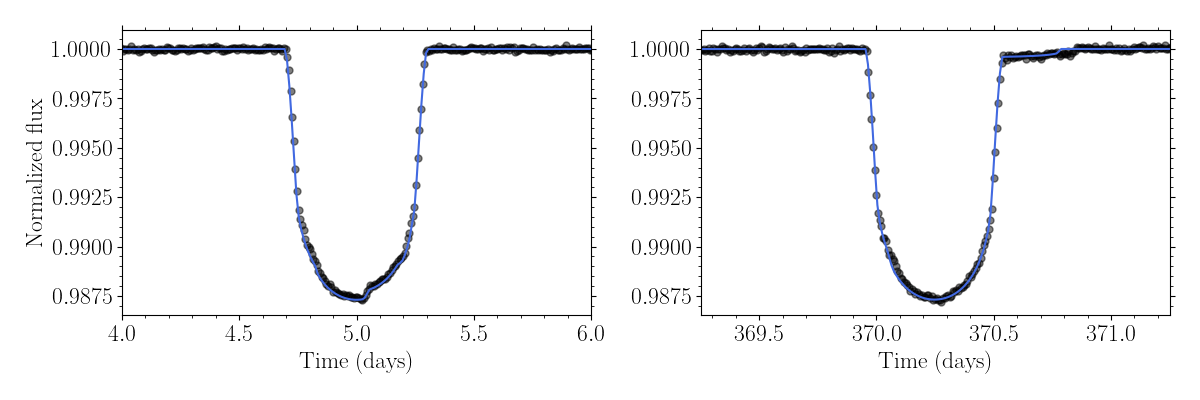

In [295]:
params = pandora.model_params()
# Stellar parameters
params.R_star = R_star
params.u1     = 0.4089
params.u2     = 0.2556
# Planet paramters
params.r_planet = R_planet / R_star  # [R_star]
params.a_bary   = a_planet / R_star  # [R_star]
params.M_planet = M_planet   # [kg]
params.per_bary = P_planet   # [d]
params.t0_bary  = 5          # [d]
params.t0_bary_offset = 0.0  # [d]
params.b_bary   = 0.0        # [0..1]
params.w_bary   = 0.0        # [deg]
params.ecc_bary = 0.0        # [0..1]  
# Moon paramters
params.r_moon     = R_moon / R_star  # [R_star]
params.M_moon     = M_moon   # [kg]
params.per_moon   = P_moon   # [d]
params.tau_moon   = 0.0      # [0..1]
params.Omega_moon = 0        # [0..180] deg
params.i_moon     = 90       # [!0,180] deg
params.e_moon     = 0.0      # [0, 1]
params.w_moon     = 0        # [0, 180] deg
# Oteher parameters
params.epochs                 = 2         # [int]
params.epoch_duration         = 2         # [days]
params.cadences_per_day       = 100       # [int]
params.epoch_distance         = P_planet  # [days]
params.supersampling_factor   = 1         # [int]
params.occult_small_threshold = 0.1       # [0..1]
params.hill_sphere_threshold  = 1.2
# Generate model
time = pandora.time(params).grid()
model = pandora.moon_model(params)
injected_flux_total, injected_flux_planet, injected_flux_moon = model.light_curve(time)
di = pd.DataFrame({'time':time, 'flux':injected_flux_total})
moon.plot_epochs(df0, di, n_epoch, T_epoch, t0, P, figsize=(12,4));

Load data frame into exomoon class

In [296]:
from platosim.varsource import Exomoon
moon = Exomoon(df.time)

Plot simulated light curve with input model

<IPython.core.display.Javascript object>


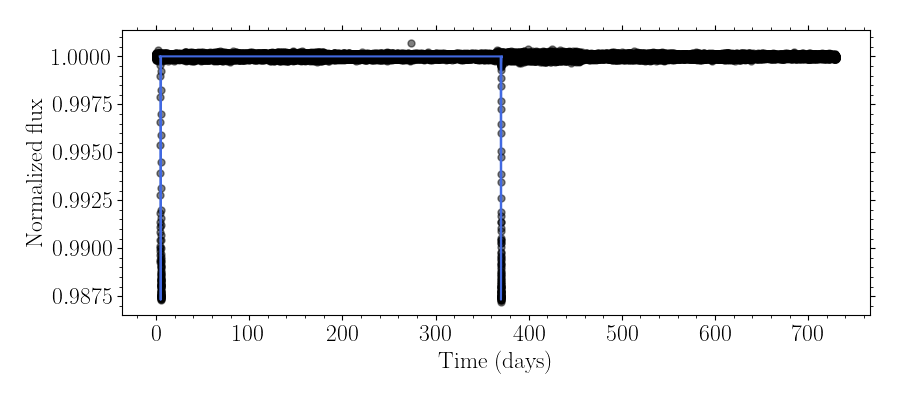

In [297]:
moon.plot_lc(df, di);

First we cut out the data around each transit

In [206]:
T_epoch = 2 * T_tot
n_epoch = round(np.floor( (t0 + t_dur) / P))
df0 = moon.cut_out_transits(df, P, t0, T_epoch)

<IPython.core.display.Javascript object>


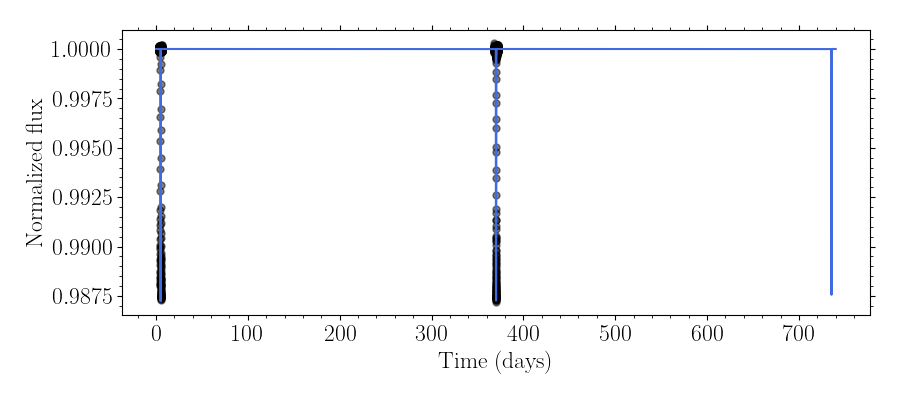

In [207]:
moon.plot_lc(df0, dv);

We can zoom-in on each transit epoch with:

<IPython.core.display.Javascript object>


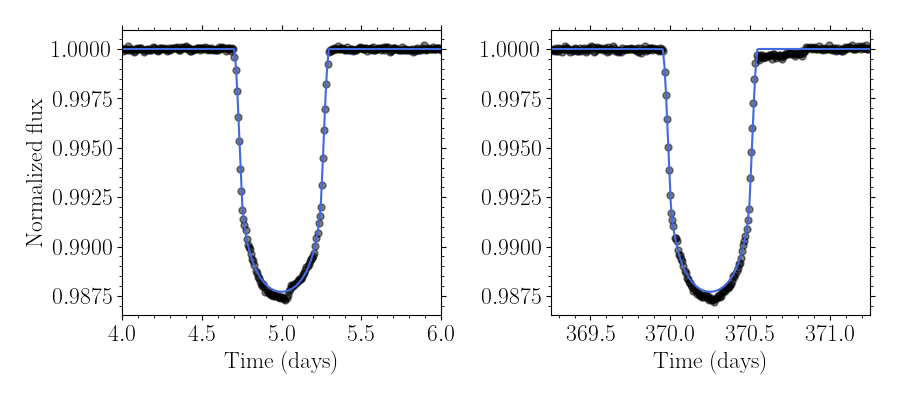

In [250]:
moon.plot_epochs(df0, di, n_epoch, T_epoch, t0, P);

## Retrieve planet-only model with UltraNest + Pandora

In [155]:
time = df0.time.to_numpy()
testdata = df0.flux.to_numpy()
yerr = np.full(len(testdata), 500e-6)
rdir = path / 'results' / 'mag085' / 'planet_only'

In [213]:
parameters = [
    'per_bary', 
    'a_bary', 
    'r_planet',
    'b_bary',
    't0_bary_offset',
    'q1',
    'q2'
]
wrapped_params = [
    False,
    False, 
    False, 
    False, 
    False, 
    False, 
    False
]
def prior_transform(cube):
    p    = cube.copy()
    P_low, P_upp = P-10, P+10
    a_low, a_upp = P-1, P+1
    R_low, R_upp = (R_planet/R_sun)-0.01, (R_planet/R_sun)+0.01
    t0_low, t0_upp = 0.05, 0.10
    p[0] = cube[0] * (P_upp-P_low) + P_low   # P_bary [days]
    p[1] = cube[1] * (a_upp-a_low) + a_low   # a_bary [R_star]
    p[2] = cube[2] * (R_upp-a_low) + R_low   # R_planet [R_star]
    p[3] = cube[3] * 1              # b_bary [0..1]
    p[4] = cube[4] * (t0_upp-t0_low) - t0_low   # t0_bary_offset [days]
    p[5] = cube[5]                  # LD q1 [0..1]
    p[6] = cube[6]                  # LD q2 [0..1]
    return p

In [214]:
R_planet/R_sun

0.00010039750582328798

In [215]:
def log_likelihood(p):
    # Convert q priors to u LDs (Kipping 2013)
    q1 = p[5]
    q2 = p[6]
    u1, u2 = ld_convert(q1, q2)

    # Calculate pandora model with trial parameters
    _, _, flux_trial_total, _, _, _, _ = pandora.pandora(
        R_star = R_sun,
        u1 = u1,
        u2 = u2,

        # Planet parameters
        per_bary = p[0],
        a_bary = p[1],
        r_planet = p[2],
        b_bary = p[3],
        w_bary = 0,
        ecc_bary = 0,
        t0_bary = params.t0_bary,
        t0_bary_offset = p[4],   
        M_planet = 1e27,

        # Moon parameters
        r_moon = 1e-8,  # negligible moon size
        per_moon = 30,  # other moon params do not matter
        tau_moon = 0,
        Omega_moon = 0,
        i_moon = 0,
        ecc_moon = 0,
        w_moon = 0,
        M_moon = 1e-8,  # negligible moon mass

        # Other model parameters
        epoch_distance = params.epoch_distance,
        supersampling_factor = 1,
        occult_small_threshold = 0.01,
        hill_sphere_threshold=1.0,
        numerical_grid=25,
        time=time,
        #cache=cache  # Can't use cache because free LDs
    )
    loglike = -0.5 * np.nansum(((flux_trial_total - testdata) / yerr)**2)
    return loglike

In [216]:
sampler = ReactiveNestedSampler(
            parameters,
            log_likelihood, 
            prior_transform,
            wrapped_params=wrapped_params,
            log_dir=rdir,
            resume='overwrite'
            )
sampler.stepsampler = ultranest.stepsampler.RegionSliceSampler(
    nsteps=1000,
    adaptive_nsteps='move-distance',
    )  

In [217]:
result_planet_only = sampler.run(min_num_live_points=800)

[ultranest] Sampling 800 live points from prior ...
[ultranest] Explored until L=-4e+04  
[ultranest] Likelihood function evaluations: 800
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -3.828e+04 +- 2.657e-12
[ultranest] Effective samples strategy satisfied (ESS = 800.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.03 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 57 minimum live points (dlogz from 0.00 to 0.00, need <0.5)
[ultranest]   logZ error budget: single: inf bs:0.00 tail:0.69 total:0.69 required:<0.50
[ultranest] done iterating.


In [218]:
sampler.print_results()


logZ = -38277.752 +- 0.693
  single instance: logZ = -38277.752 +- nan
  bootstrapped   : logZ = -38277.752 +- -0.000
  tail           : logZ = +- 0.693
insert order U test : converged: True correlation: inf iterations
diagnostic unavailable, no recorded steps found

    per_bary            : 355.3 │▆▆▆▅▅▆▄▆▆▅▅▄▄▆▆▅▄▆▆▆▄▇▄▅▇▅▅▆▆▅▆▅▄▅▅▄▄▇▄│375.2     365.1 +- 5.8
    a_bary              : 364.25│▅▇▆▅▅▅▅▇▆▅▅▅▄▅▄▆▄▅▄▅▅▅▅▆▆▅▅▄▆▄▇▄▅▅▄▅▅▅▅│366.25    365.22 +- 0.59
    r_planet            -178 +- 105
    b_bary              : 0.00  │▅▅▇▄▅▇▄▅▅▅▅▆▄▅▆▅▄▆▅▆▇▆▅▅▅▇▄▄▅▄▇▄▆▄▆▆▇▆▆│1.00      0.50 +- 0.29
    t0_bary_offset      : -0.050│▄▅▄▅▄▅▇▆▄▅▆▄▄▃▄▅▅▇▅▄▅▃▄▃▆▅▄▄▄▅▅▃▅▃▆▅▃▅▆│-0.000    -0.025 +- 0.015
    q1                  : 0.00  │▆▇▅▄▅▅▄▆▇▆▅▄▃▄▅▄▅▆▃▃▆▆▃▇▅▄▄▆▅▅▆▆▄▇▅▅▆▄▆│1.00      0.50 +- 0.30
    q2                  : 0.00  │▅▄▄▄▄▆▃▃▄▇▆▄▄▅▄▅▅▅▅▅▇▅▄▃▃▅▄▄▅▃▅▆▅▇▃▄▄▅▄│1.00      0.50 +- 0.28



<IPython.core.display.Javascript object>


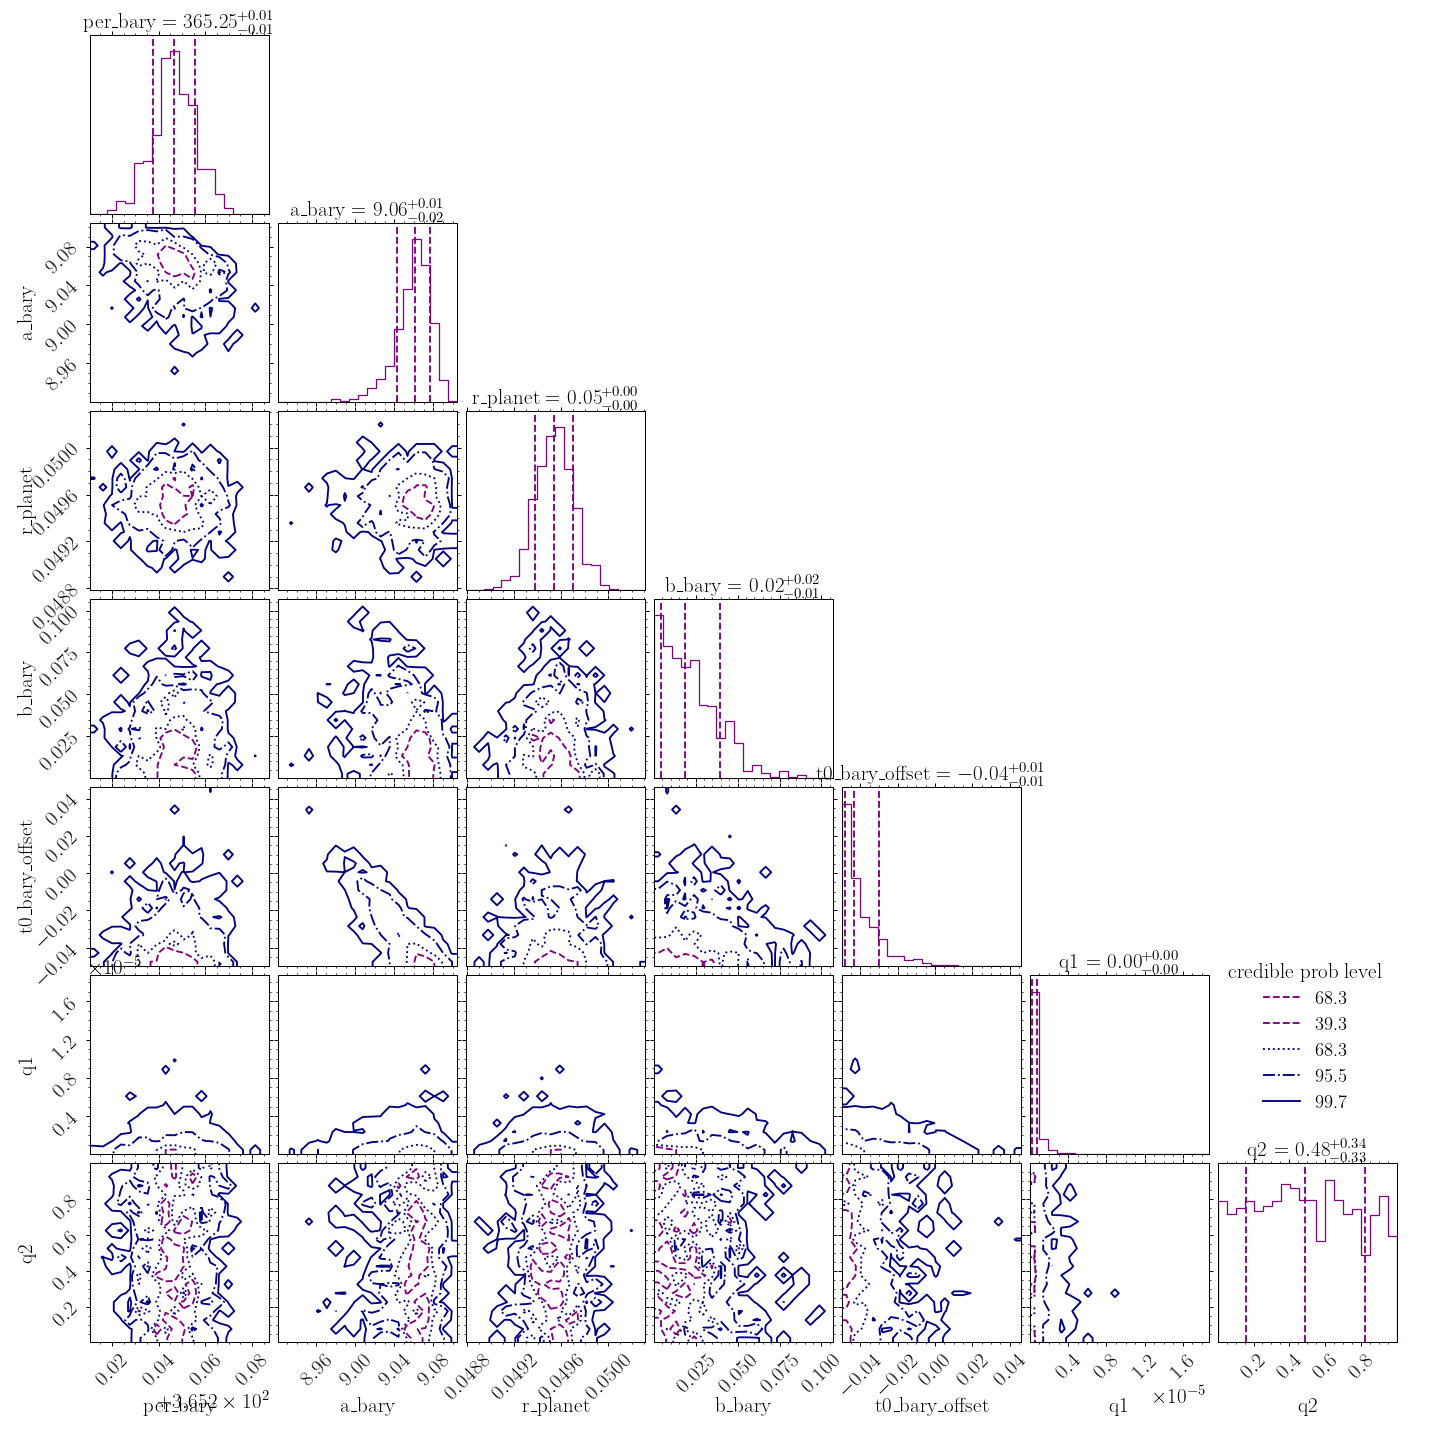

In [166]:
cornerplot(result_planet_only);

In [164]:
filename = rdir / "info/results.json"
with open(filename, 'r') as g:
    results_planet_only = json.load(g)
print("Planet-only logz:", results_planet_only["logz"])

Planet-only logz: -29791.668552552288


In [168]:
print(results_planet_only["paramnames"])

['per_bary', 'a_bary', 'r_planet', 'b_bary', 't0_bary_offset', 'q1', 'q2']


In [167]:
mll_planet_only_per_bary = results_planet_only["maximum_likelihood"]["point"][0]
mll_planet_only_a_bary   = results_planet_only["maximum_likelihood"]["point"][1]
mll_planet_only_r_planet = results_planet_only["maximum_likelihood"]["point"][2]
mll_planet_only_b_bary   = results_planet_only["maximum_likelihood"]["point"][3]
mll_planet_only_t0_bary_offset = results_planet_only["maximum_likelihood"]["point"][4]
mll_planet_only_q1       = results_planet_only["maximum_likelihood"]["point"][5]
mll_planet_only_q2       = results_planet_only["maximum_likelihood"]["point"][6]

print("Maximum likelihoods for planet-only fit:")
print("per_bary", mll_planet_only_per_bary)
print("a_bary", mll_planet_only_a_bary)
print("r_planet", mll_planet_only_r_planet)
print("b_bary", mll_planet_only_b_bary)
print("t0_bary_offset", mll_planet_only_t0_bary_offset)
print("q1", mll_planet_only_q1)
print("q2", mll_planet_only_q2)

Maximum likelihoods for planet-only fit:
per_bary 365.2509196142552
a_bary 9.076650086543461
r_planet 0.049490965024240476
b_bary 0.008902838025803555
t0_bary_offset -0.04983029182313723
q1 6.643815186143311e-09
q2 0.24581600279620325


In [174]:
params = pandora.model_params()
R_sun = 696_342_000
params.R_star = R_sun  # [m]

# Convert limb darkening back from q to u type:
u1, u2 = ld_invert(mll_planet_only_q1, mll_planet_only_q2)
params.u1 = u1
params.u2 = u2

# Planet parameters
params.per_bary = mll_planet_only_per_bary  # [days]
params.a_bary = mll_planet_only_a_bary  # [R_star]
params.r_planet = mll_planet_only_r_planet # [R_star]
params.b_bary = mll_planet_only_b_bary   # [0..1]
params.t0_bary = 11  # [days]
params.t0_bary_offset = mll_planet_only_t0_bary_offset  # [days]
params.M_planet = 1e27  # [kg]
params.w_bary = 0  # [deg]
params.ecc_bary = 0.0  # [0..1]  

# Moon parameters
params.r_moon = 1e-8  # negligible moon size
params.per_moon = 30  # other moon params do not matter
params.tau_moon = 0
params.Omega_moon = 0
params.i_moon = 0
params.ecc_moon = 0
params.w_moon = 0
params.M_moon = 1e-8  # negligible moon mass

# Other model parameters
params.epochs = 3  # [int]
params.epoch_duration = 2  # [days]
params.cadences_per_day = 48  # [int]
params.epoch_distance = 365.26   # [days]
params.supersampling_factor = 1  # [int]
params.occult_small_threshold = 0.1  # [0..1]
params.hill_sphere_threshold = 1.2

# Obtain time grid
# time = pandora.time(params).grid()
time = df0.time.to_numpy()

# Define model
model = pandora.moon_model(params)

# Evaluate model for each point in time grid
po_flux_total, po_flux_planet, po_flux_moon = model.light_curve(time)

<IPython.core.display.Javascript object>


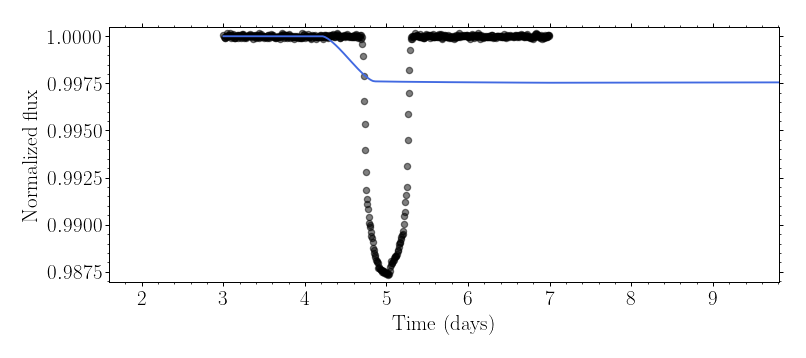

(<Figure size 900x400 with 1 Axes>,
 <Axes: xlabel='Time (days)', ylabel='Normalized flux'>)

In [177]:
dv_planet = pd.DataFrame({'time': df0.time, 'flux':po_flux_total})
moon.plot_lc(df0, dv_planet)

# fig, axs = plt.subplots(2, 3, figsize=(9,6))
# axs[0,0].plot(time, po_flux_planet, color="blue")
# axs[0,0].plot(time, po_flux_moon, color="red")
# axs[0,0].plot(time, po_flux_total, color="black")
# axs[0,0].scatter(time, testdata, color="black", s=0.5)
# axs[0,0].set_xlim(min(time), min(time)+params.epoch_duration)
# axs[1,0].scatter(time, po_flux_total-testdata, color="black", s=0.5)
# axs[1,0].set_xlim(min(time), min(time)+params.epoch_duration)

# axs[0,1].plot(time, po_flux_planet, color="blue")
# axs[0,1].plot(time, po_flux_moon, color="red")
# axs[0,1].plot(time, po_flux_total, color="black")
# axs[0,1].scatter(time, testdata, color="black", s=0.5)
# axs[0,1].set_xlim(min(time)+params.epoch_distance, min(time)+params.epoch_duration+params.epoch_distance)
# axs[1,1].scatter(time, po_flux_total-testdata, color="black", s=0.5)
# axs[1,1].set_xlim(min(time)+params.epoch_distance, min(time)+params.epoch_duration+params.epoch_distance)

# axs[0,2].plot(time, po_flux_planet, color="blue")
# axs[0,2].plot(time, po_flux_moon, color="red")
# axs[0,2].plot(time, po_flux_total, color="black")
# axs[0,2].scatter(time, testdata, color="black", s=0.5)
# axs[0,2].set_xlim(min(time)+2*params.epoch_distance, min(time)+params.epoch_duration+2*params.epoch_distance)
# axs[1,2].scatter(time, po_flux_total-testdata, color="black", s=0.5)
# axs[1,2].set_xlim(min(time)+2*params.epoch_distance, min(time)+params.epoch_duration+2*params.epoch_distance)

# plt.tight_layout();